# Exploratory Data Analysis (EDA)

## Overview

Exploratory Data Analysis (EDA) dilakukan untuk memahami pola, distribusi, hubungan, dan karakteristik data setelah melalui proses data cleaning dan feature engineering.

EDA digunakan sebagai tahap awal untuk menemukan pola atau kondisi yang perlu dianalisis lebih lanjut sebelum masuk ke business analysis.

### EDA Workflow

**Feature-Engineered Dataset**
↓
**Numerical Analysis**
↓
**Categorical Analysis**
↓
**Distribution Analysis**
↓
**Correlation Analysis**
↓
**EDA Findings**
↓
**Business Analysis**

### Analisis yang Dilakukan

* Analisis statistik variabel numerik
* Analisis distribusi data
* Analisis variabel kategorikal
* Analisis hubungan antar variabel
* Identifikasi pola dan anomali
* Menentukan temuan yang perlu dianalisis lebih lanjut

### Output

Hasil EDA digunakan sebagai dasar untuk menentukan analisis bisnis pada tahap berikutnya.


In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)


In [3]:
df = pd.read_csv("../Dataset/data_fetures.csv")
df.head()

,order_id,order_date,customer_id,customer_name,customer_gender,customer_age,customer_city,customer_province,product_id,product_name,category,sub_category,unit_price,quantity,discount_percent,shipping_cost,total_amount,payment_method,order_status,delivery_date,rating,order_month,order_year,order_month_name,gross_amount,discount_amount,delivery_days,customer_age_group
0,ORD0016487,2023-01-01,C006565,KH. Kemal Prayoga,Perempuan,23,Bontang,Kalimantan Timur,P01246,Rok Delectus Edisi Spesial,Fashion Wanita,Rok,491124,1,0,9000,491100,Transfer Bank,Selesai,2023-01-06,4.0,1,2023,January,491124,0.0,5.0,20-29
1,ORD0002315,2023-01-01,C007249,"Budi Siregar, S.IP",Laki-laki,29,Gianyar,Bali,P01451,Perawatan Rambut Vel Premium,Kecantikan,Perawatan Rambut,432811,2,20,12000,692500,E-Wallet,Selesai,2023-01-04,2.0,1,2023,January,865622,173124.4,3.0,20-29
2,ORD0045934,2023-01-01,C004568,"Cut Maria Irawan, S.T.",Perempuan,50,Jakarta Utara,DKI Jakarta,P01700,Alat Tulis Doloremque Plus,Buku & Alat Tulis,Alat Tulis,71602,3,10,12000,193300,Transfer Bank,Selesai,2023-01-04,5.0,1,2023,January,214806,21480.6,3.0,50-59
3,ORD0001080,2023-01-01,C005280,Dr. Edward Simanjuntak,Laki-laki,38,Samarinda,Kalimantan Timur,P01381,Perlengkapan Mandi Dolore Plus,Rumah Tangga,Perlengkapan Mandi,1369838,1,10,25000,1232900,E-Wallet,Selesai,2023-01-07,4.0,1,2023,January,1369838,136983.8,6.0,30-39
4,ORD0007869,2023-01-01,C010669,Shakila Wahyudin,Perempuan,52,Palembang,Sumatera Selatan,P01681,Buku Non-Fiksi Libero Premium,Buku & Alat Tulis,Buku Non-Fiksi,145639,1,20,9000,116500,Transfer Bank,Selesai,2023-01-04,5.0,1,2023,January,145639,29127.8,3.0,50-59


# Univariat Analisis

1. Numerical Analysis

In [4]:
numerical_cols = [
    "customer_age",
    "unit_price",
    "quantity",
    "discount_percent",
    "shipping_cost",
    "total_amount",
    "gross_amount",
    "discount_amount",
    "delivery_days"
]

In [5]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
customer_age,50000.0,3.845632e+01,1.208293e+01,18.0,28.0,39.0,49.000,59.0
unit_price,50000.0,1.448859e+06,2.811401e+06,6920.0,162217.0,452955.0,1197522.000,14952022.0
quantity,50000.0,1.834420e+00,1.132903e+00,1.0,1.0,1.0,2.000,5.0
discount_percent,50000.0,8.701600e+00,8.573192e+00,0.0,0.0,10.0,15.000,30.0
shipping_cost,50000.0,1.127740e+04,7.259913e+03,0.0,9000.0,12000.0,15000.000,25000.0
total_amount,50000.0,2.409668e+06,5.704542e+06,4800.0,213400.0,578800.0,1756600.000,68366800.0
gross_amount,50000.0,2.644983e+06,6.249432e+06,6920.0,234654.0,628670.0,1905486.000,74760110.0
discount_amount,50000.0,2.353152e+05,8.187331e+05,0.0,0.0,23367.5,125319.825,22190992.5
delivery_days,42040.0,3.988582e+00,1.997051e+00,1.0,2.0,4.0,6.000,7.0


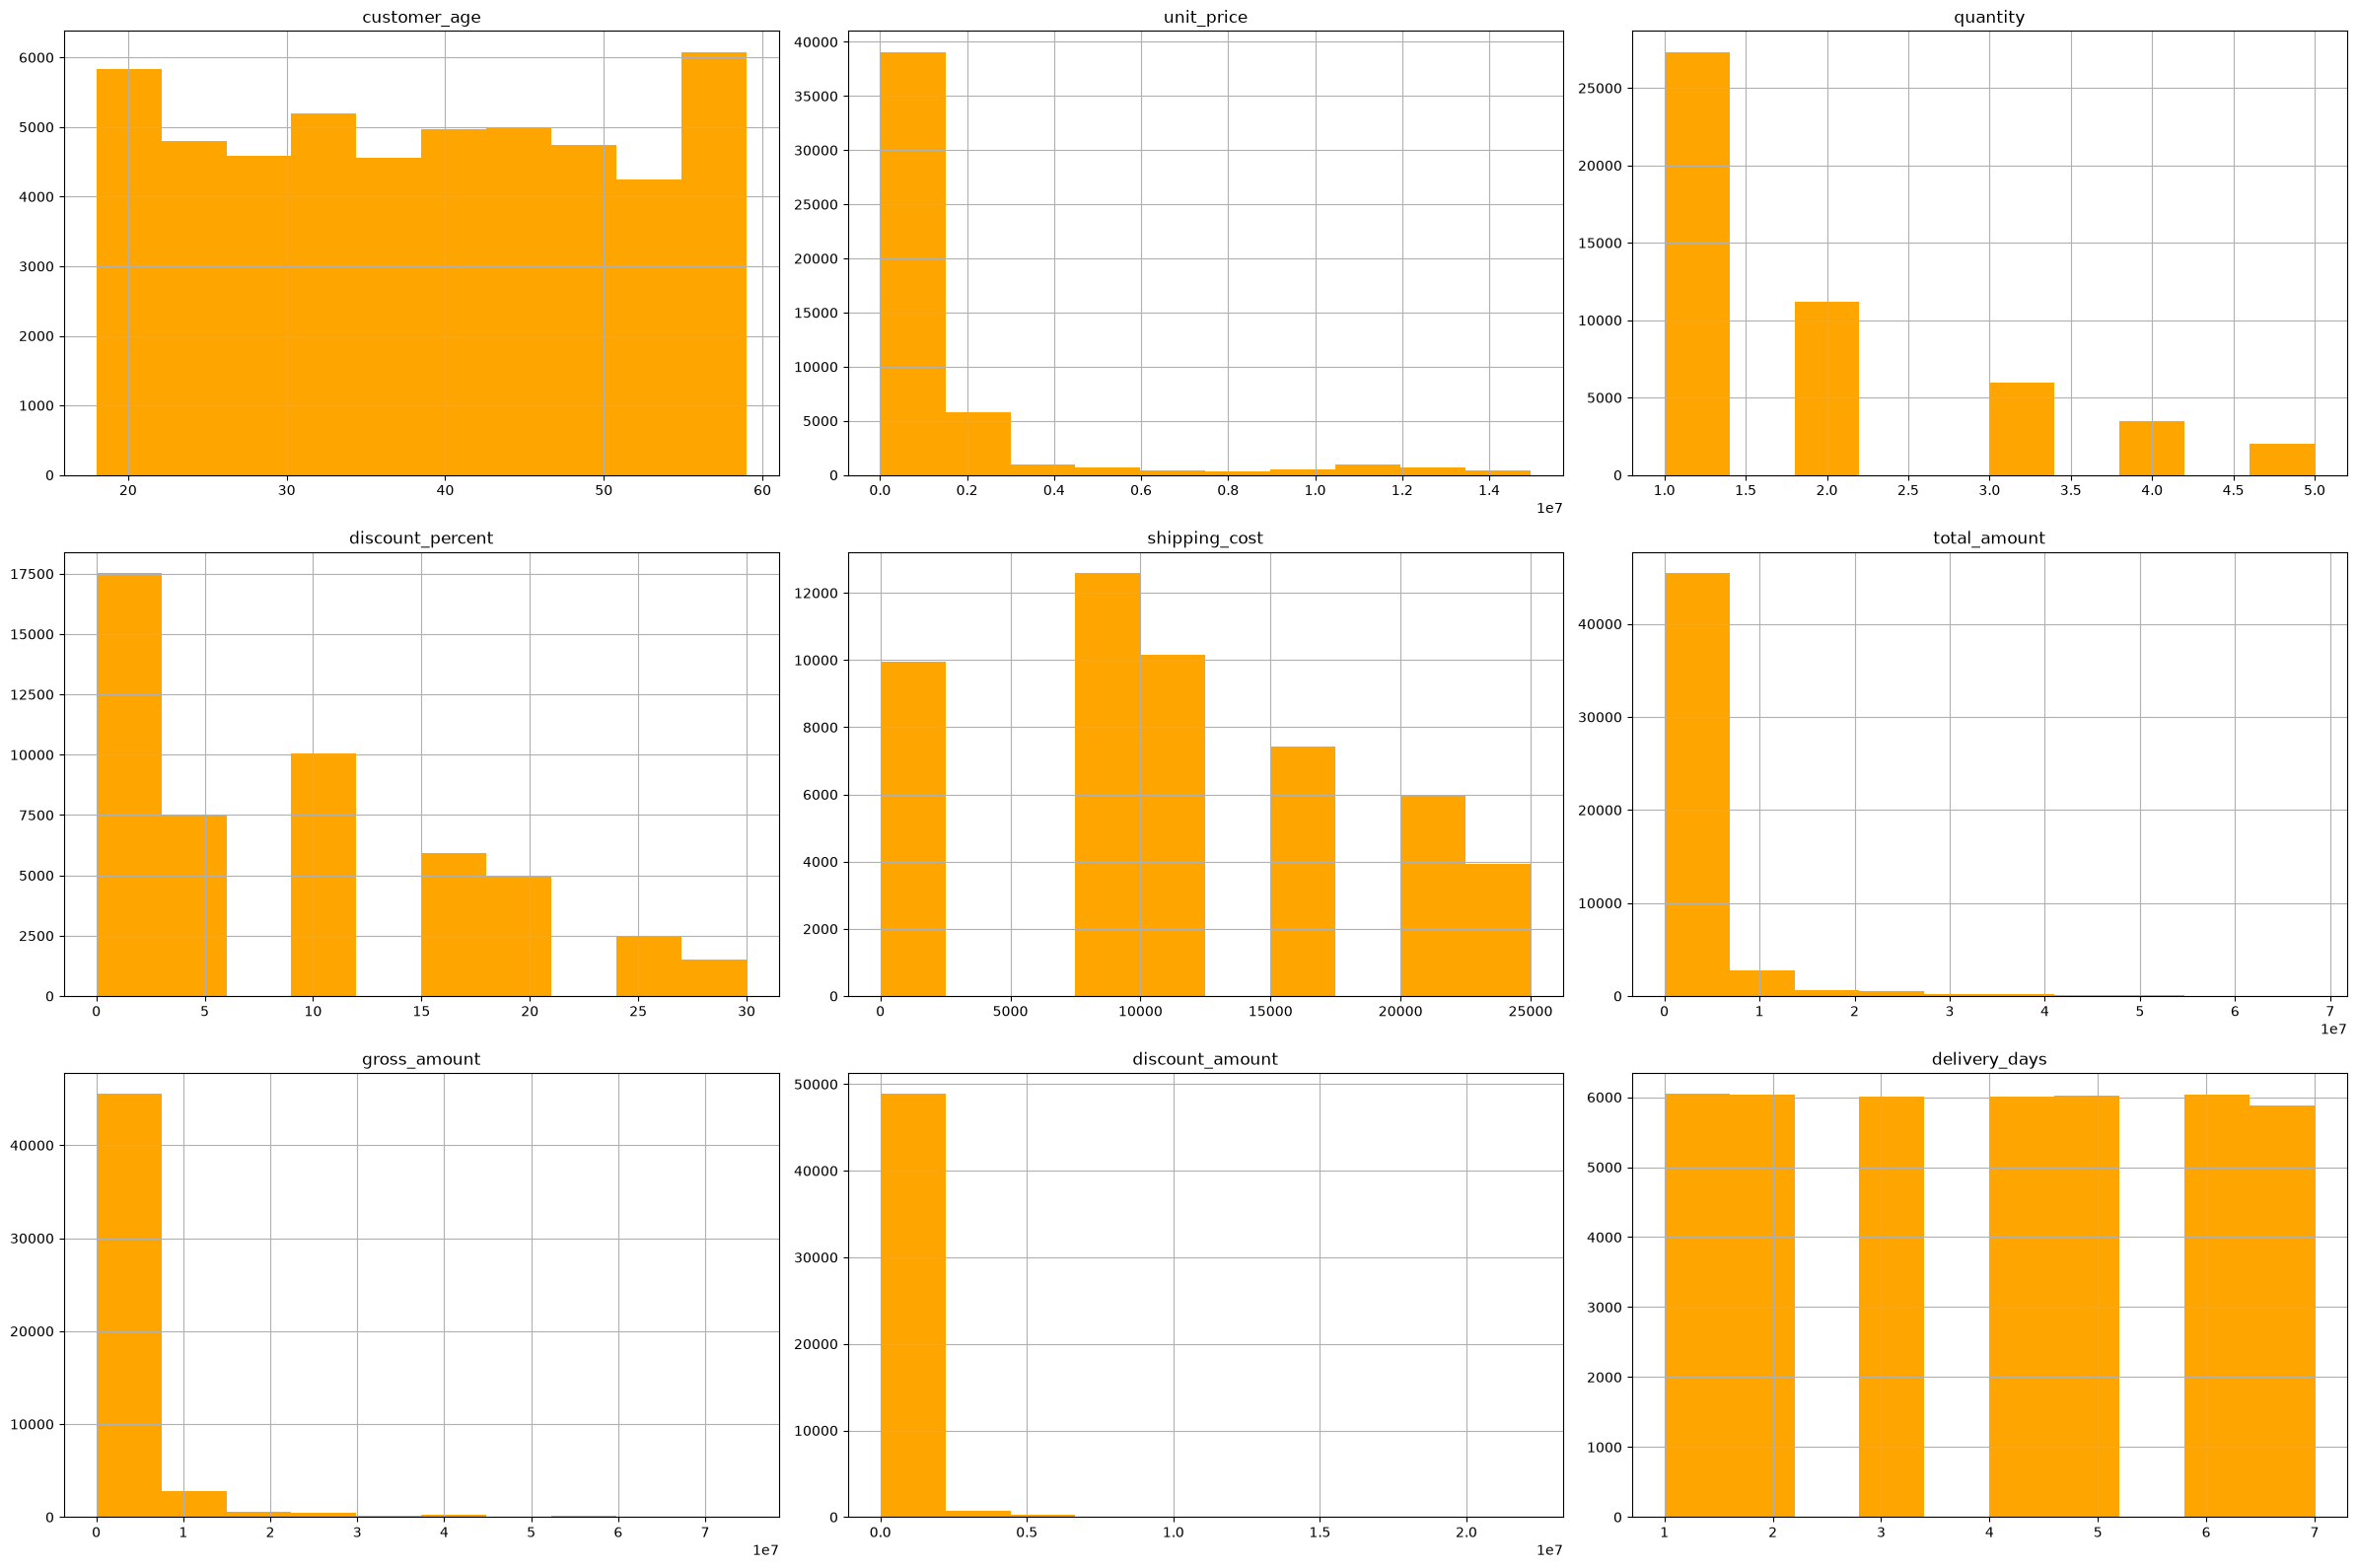

In [6]:
df[numerical_cols].hist(
    figsize=(24, 16),
    color="orange"

)

plt.tight_layout()
plt.show()

In [7]:
df[numerical_cols].skew()

customer_age        0.017892
unit_price          3.077594
quantity            1.286844
discount_percent    0.708113
shipping_cost       0.005273
total_amount        5.211044
gross_amount        5.174258
discount_amount     8.595258
delivery_days       0.004071
dtype: float64

Berdasarkan hasil analisis skewness, sebagian besar variabel memiliki distribusi yang relatif simetris hingga moderately skewed. customer_age (0.018), shipping_cost (0.005), order_month (-0.015), order_year (0.000), dan delivery_days (0.004) memiliki nilai skewness yang mendekati 0, sehingga distribusinya cenderung simetris. quantity (1.287) menunjukkan positive skewness, yang mengindikasikan sebagian besar transaksi memiliki jumlah pembelian yang relatif kecil, sementara sebagian kecil transaksi memiliki quantity yang jauh lebih besar.

Variabel unit_price (3.078), total_amount (5.211), gross_amount (5.174), discount_amount (8.595), dan discount_percent (0.708) menunjukkan positive skewness, dengan discount_amount, total_amount, gross_amount, dan unit_price memiliki tingkat kemencengan yang cukup tinggi. Hal ini mengindikasikan adanya sejumlah kecil transaksi dengan nilai yang jauh lebih tinggi dibandingkan mayoritas data.

Sementara itu, rating memiliki skewness -1.385, yang menunjukkan negative skewness. Artinya, distribusi rating cenderung terkonsentrasi pada nilai yang relatif tinggi, dengan sebagian kecil observasi memiliki rating yang rendah.

Secara keseluruhan, beberapa variabel finansial seperti unit_price, total_amount, gross_amount, dan terutama discount_amount memiliki distribusi yang sangat positively skewed. Kondisi ini perlu diperhatikan pada tahap analisis lanjutan karena nilai ekstrem dapat memengaruhi statistik seperti mean dan performa beberapa algoritma machine learning.

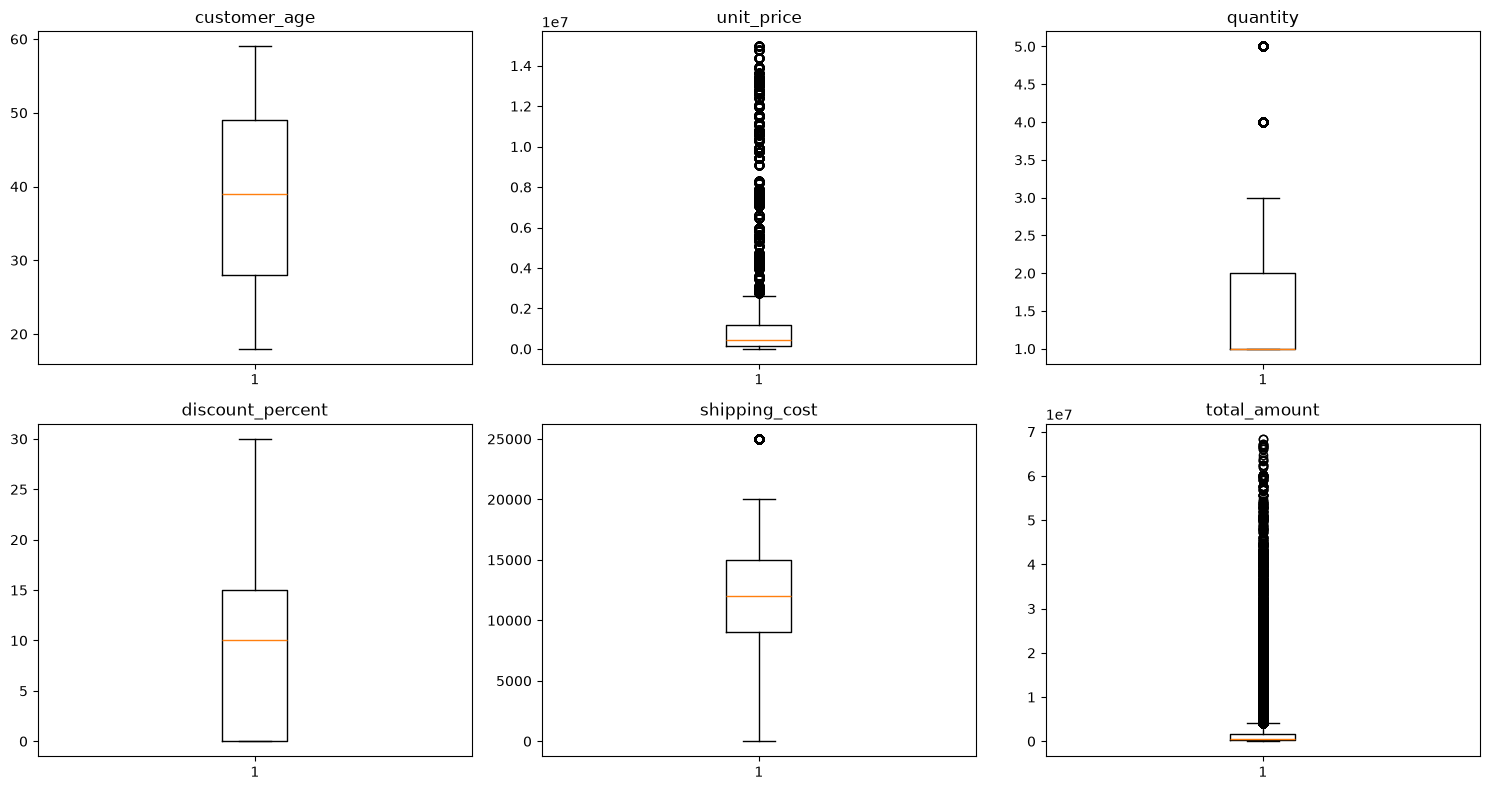

In [8]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 8)
)

for ax, col in zip(axes.flat, numerical_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)

for ax in axes.flat[len(numerical_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

In [9]:
outlier_summary = []

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (
        (df[col] < lower) |
        (df[col] > upper)
    )

    outlier_summary.append({
        "column": col,
        "outlier_count": mask.sum(),
        "outlier_percentage": mask.mean() * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary

,column,outlier_count,outlier_percentage
0,customer_age,0,0.000
1,unit_price,5797,11.594
2,quantity,5534,11.068
3,discount_percent,0,0.000
4,shipping_cost,3946,7.892
5,total_amount,6711,13.422
6,gross_amount,6790,13.580
7,discount_amount,6899,13.798
8,delivery_days,0,0.000


Berdasarkan hasil deteksi outlier, beberapa variabel numerik memiliki jumlah outlier yang cukup signifikan. Variabel customer_age, discount_percent, order_month, order_year, dan delivery_days tidak memiliki outlier berdasarkan metode IQR. Sementara itu, unit_price memiliki 5.797 outlier (11,59%), quantity sebanyak 5.534 (11,07%), dan shipping_cost sebanyak 3.946 (7,89%).

Variabel dengan jumlah outlier terbesar terdapat pada discount_amount sebanyak 6.899 (13,80%), diikuti gross_amount sebanyak 6.790 (13,58%) dan total_amount sebanyak 6.711 (13,42%). rating juga memiliki 2.496 outlier (4,99%). Tingginya jumlah outlier pada variabel finansial seperti total_amount, gross_amount, dan discount_amount perlu diperhatikan karena dapat mencerminkan transaksi dengan nilai yang relatif ekstrem dibandingkan mayoritas data.

Namun, outlier yang terdeteksi secara statistik tidak langsung dianggap sebagai kesalahan data. Variabel seperti unit_price, quantity, dan nilai transaksi dapat memiliki nilai ekstrem yang valid secara bisnis, misalnya pembelian dalam jumlah besar atau produk dengan harga tinggi. Oleh karena itu, diperlukan investigasi lebih lanjut terhadap konteks transaksi sebelum menentukan apakah outlier akan dipertahankan, dikoreksi, atau dihapus.

2. Categorical Analysis

In [42]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10024\2011215904.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


['order_id',
 'order_date',
 'customer_id',
 'customer_name',
 'customer_gender',
 'customer_city',
 'customer_province',
 'product_id',
 'product_name',
 'category',
 'sub_category',
 'payment_method',
 'order_status',
 'delivery_date',
 'order_month_name',
 'customer_age_group']

In [45]:
categorical_analisis = [
    "customer_gender",
    "customer_city",
    "customer_province",
    "category",
    "sub_category",
    "payment_method",
    "order_status",
    "customer_age_group"
]


In [60]:
df[categorical_analisis].nunique()

customer_gender        2
customer_city         45
customer_province     15
category               8
sub_category          35
payment_method         5
order_status           4
customer_age_group     5
dtype: int64

2.1 Analisis customer gender

In [51]:
df["customer_gender"].unique()

<StringArray>
['Perempuan', 'Laki-laki']
Length: 2, dtype: str

In [52]:
df["customer_gender"].value_counts()

customer_gender
Laki-laki    25614
Perempuan    24386
Name: count, dtype: int64

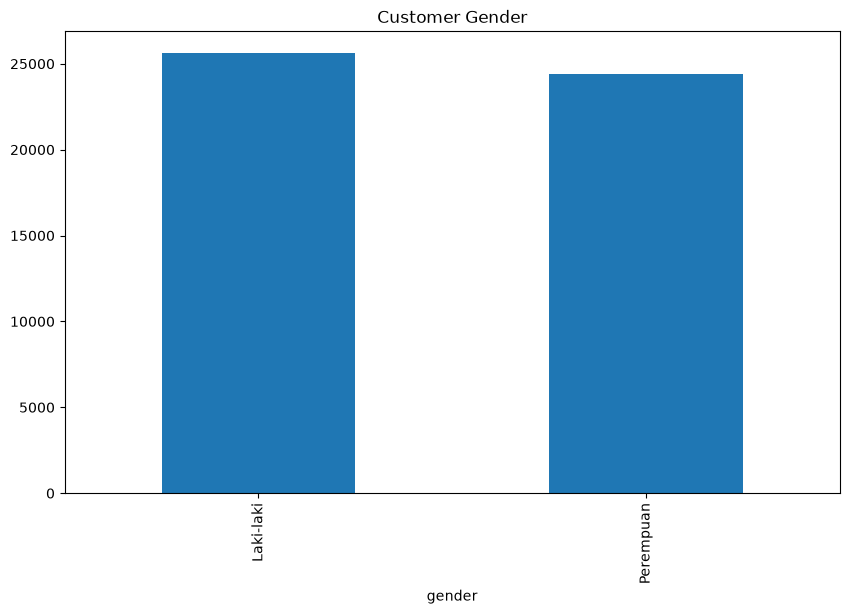

In [53]:
df["customer_gender"].value_counts().plot(
    kind='bar',
    figsize=(10, 6)
)
plt.title("Customer Gender")
plt.xlabel("gender")
plt.show()

2.2 Analisis Customer City

In [64]:
df["customer_city"].unique()

<StringArray>
[        'Bontang',         'Gianyar',   'Jakarta Utara',       'Samarinda',
       'Palembang',        'Denpasar',           'Metro',          'Badung',
          'Bekasi',          'Padang',        'Makassar',            'Solo',
      'Yogyakarta',        'Magelang',  'Bandar Lampung',           'Tegal',
       'Tangerang',        'Surabaya',        'Parepare',     'Bukittinggi',
       'Pekanbaru',           'Dumai',          'Malang',          'Bantul',
         'Bandung',    'Lubuklinggau', 'Jakarta Selatan',   'Jakarta Barat',
         'Cilegon',            'Bima', 'Pematangsiantar',   'Jakarta Timur',
          'Binjai',         'Mataram',           'Medan',   'Jakarta Pusat',
      'Balikpapan',          'Kediri',          'Serang',        'Sidoarjo',
           'Bogor',        'Semarang',          'Cimahi',           'Depok',
          'Sleman']
Length: 45, dtype: str

In [69]:
customer_analisis = df["customer_city"].value_counts().sort_values(ascending=False).head(10)
customer_analisis

customer_city
Padang            2268
Parepare          1727
Bandar Lampung    1707
Lubuklinggau      1706
Bima              1675
Pekanbaru         1669
Palembang         1645
Metro             1632
Mataram           1564
Makassar          1511
Name: count, dtype: int64

In [76]:
customer_analisis_precent = (df["customer_city"].value_counts(normalize=True) * 100).sort_values(ascending=False).head(10)
customer_analisis_precent

customer_city
Padang            4.536
Parepare          3.454
Bandar Lampung    3.414
Lubuklinggau      3.412
Bima              3.350
Pekanbaru         3.338
Palembang         3.290
Metro             3.264
Mataram           3.128
Makassar          3.022
Name: proportion, dtype: float64

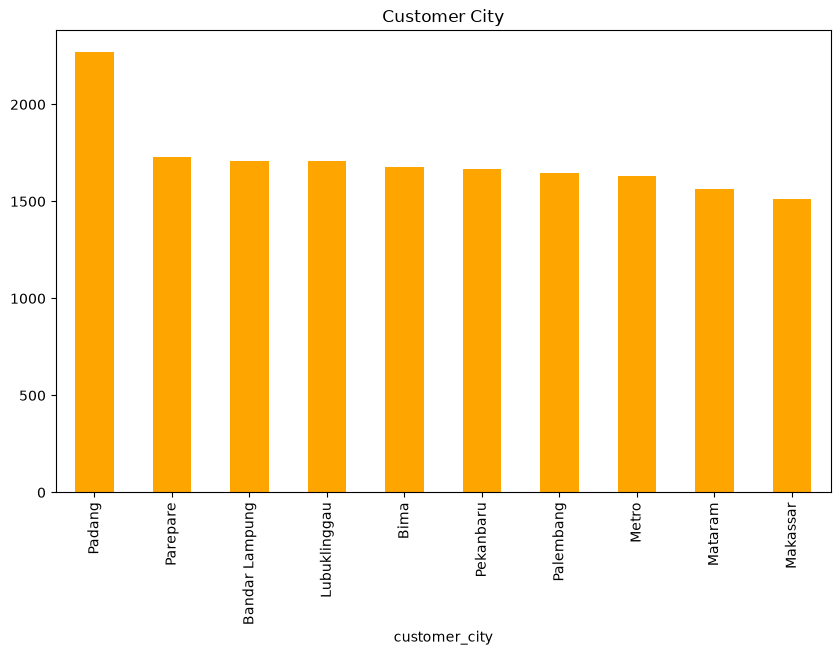

In [74]:
customer_analisis.plot(
    kind='bar',
    figsize=(10, 6),
    color="orange"
)

plt.title("Customer City")
plt.show()


2.3 Analis Provinsi

In [82]:
df["customer_province"].unique()

<StringArray>
[   'Kalimantan Timur',                'Bali',         'DKI Jakarta',
    'Sumatera Selatan',             'Lampung',          'Jawa Barat',
      'Sumatera Barat',    'Sulawesi Selatan',         'Jawa Tengah',
          'Yogyakarta',              'Banten',          'Jawa Timur',
                'Riau', 'Nusa Tenggara Barat',      'Sumatera Utara']
Length: 15, dtype: str

In [85]:
customer_provinsi_analisis = df["customer_province"].value_counts().sort_values(ascending=False).head(10)
customer_provinsi_analisis

customer_province
Jawa Tengah         3612
Banten              3492
Bali                3470
DKI Jakarta         3407
Sumatera Selatan    3385
Lampung             3366
Kalimantan Timur    3314
Sumatera Barat      3278
Sulawesi Selatan    3275
Sumatera Utara      3273
Name: count, dtype: int64

Text(0.5, 1.0, 'Customer Provinsi Top 10')

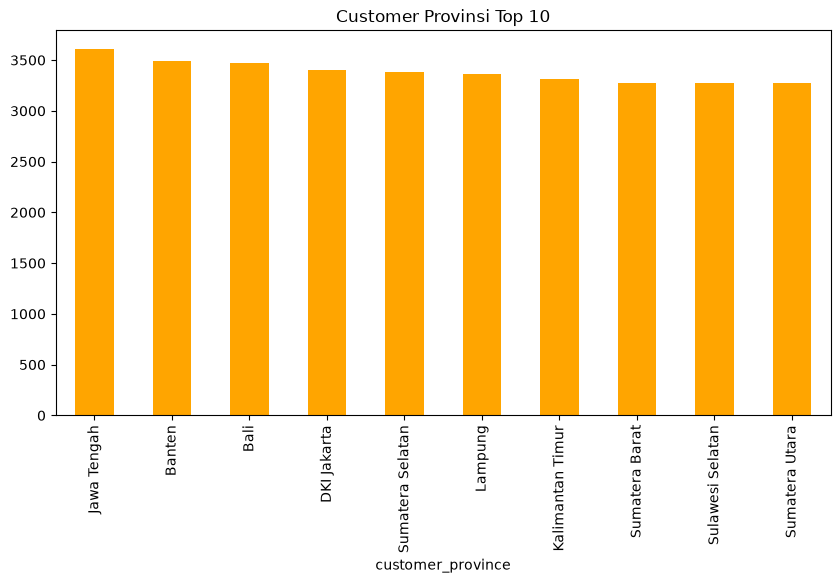

In [91]:
customer_provinsi_analisis.plot(
    kind='bar',
    figsize=(10, 5),
    color="orange"
)

plt.title("Customer Provinsi Top 10")

2.4 Analisis Category

In [92]:
df['category'].unique()


<StringArray>
[   'Fashion Wanita',        'Kecantikan', 'Buku & Alat Tulis',
      'Rumah Tangga',        'Elektronik',          'Olahraga',
 'Makanan & Minuman',      'Fashion Pria']
Length: 8, dtype: str

In [96]:
category_analisis = df["category"].value_counts()
category_analisis

category
Fashion Wanita       6917
Elektronik           6782
Fashion Pria         6753
Rumah Tangga         6025
Olahraga             5952
Makanan & Minuman    5881
Kecantikan           5849
Buku & Alat Tulis    5841
Name: count, dtype: int64

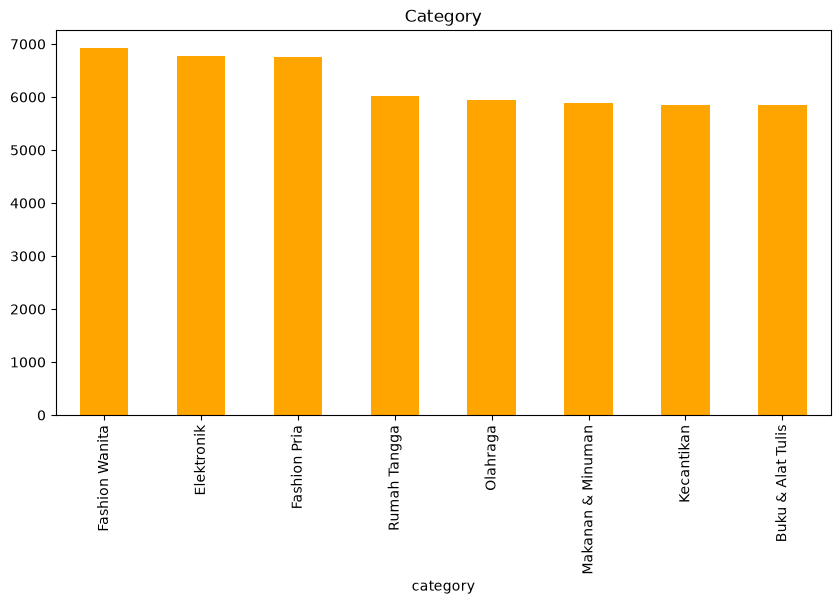

In [97]:
category_analisis.plot(
    kind='bar',
    figsize=(10, 5),
    color='orange'
)

plt.title("Category")
plt.show()

2.4 Analisis Sub Category 

In [98]:
df["sub_category"].unique()

<StringArray>
[                'Rok',    'Perawatan Rambut',          'Alat Tulis',
  'Perlengkapan Mandi',      'Buku Non-Fiksi',          'Tas Wanita',
              'Laptop',              'Sepeda',                'Blus',
     'Sepatu Olahraga',            'Dekorasi',            'Skincare',
         'Bahan Masak',               'Dress',        'Aksesoris HP',
               'Audio',               'Jaket',       'Sepatu Wanita',
                'Kaos',         'Sepatu Pria',      'Aksesoris Pria',
          'Buku Fiksi',      'Furnitur Kecil',              'Parfum',
     'Peralatan Dapur',              'Celana',              'Makeup',
      'Minuman Instan',          'Kopi & Teh', 'Perlengkapan Kantor',
               'Snack',          'Smartphone',        'Alat Fitness',
              'Kamera',    'Pakaian Olahraga']
Length: 35, dtype: str

In [101]:
sub_categori_analisis = df["sub_category"].value_counts().sort_values(ascending=False).head(10)
sub_categori_analisis

sub_category
Furnitur Kecil         1555
Sepatu Olahraga        1544
Perlengkapan Mandi     1543
Minuman Instan         1541
Alat Fitness           1527
Skincare               1503
Perlengkapan Kantor    1503
Snack                  1485
Peralatan Dapur        1481
Makeup                 1473
Name: count, dtype: int64

2.5 Analisis Payment Method

In [102]:
df["payment_method"].unique()

<StringArray>
['Transfer Bank', 'E-Wallet', 'QRIS', 'COD', 'Kartu Kredit']
Length: 5, dtype: str

In [104]:
payment_analisis = df["payment_method"].value_counts().sort_values(ascending=False)
payment_analisis

payment_method
E-Wallet         15965
Transfer Bank    14961
COD               7528
Kartu Kredit      6640
QRIS              4906
Name: count, dtype: int64

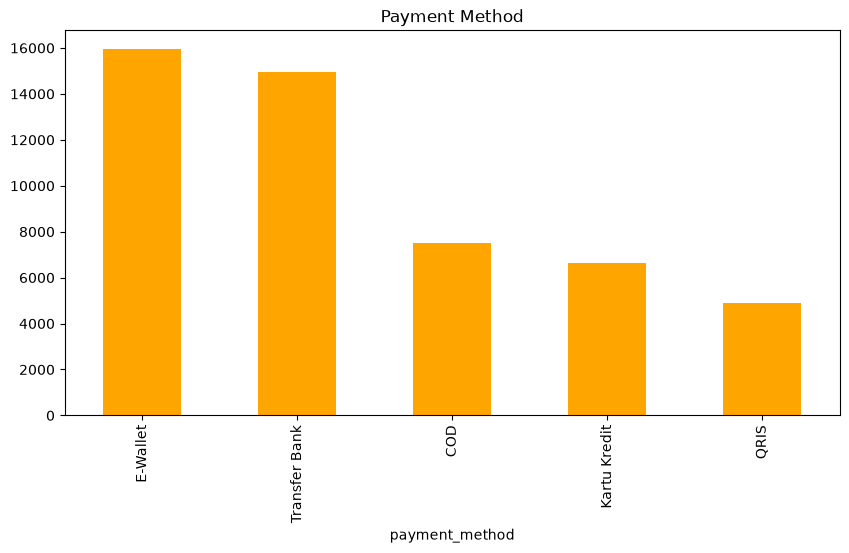

In [105]:
payment_analisis.plot(
    kind='bar',
    figsize=(10, 5),
    color='orange'
)
plt.title("Payment Method")
plt.show()

In [107]:
categorical_analisis

['customer_gender',
 'customer_city',
 'customer_province',
 'category',
 'sub_category',
 'payment_method',
 'order_status',
 'customer_age_group']

3.6 Analisis Order Status 

In [109]:
df["order_status"].unique()

<StringArray>
['Selesai', 'Dikembalikan', 'Diproses', 'Dibatalkan']
Length: 4, dtype: str

In [111]:
order_status_analisis = df["order_status"].value_counts().sort_values(ascending=False)
order_status_analisis

order_status
Selesai         39038
Diproses         3980
Dibatalkan       3980
Dikembalikan     3002
Name: count, dtype: int64

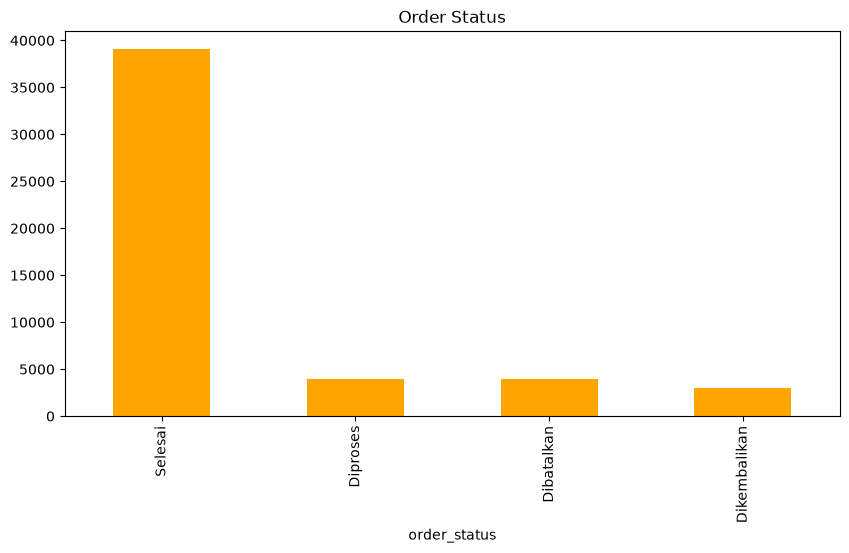

In [113]:
order_status_analisis.plot(
    kind='bar',
    figsize=(10,5),
    color='orange'
)

plt.title("Order Status")
plt.show()

# Bevariat Analisis 

In [117]:
category_sales = df.groupby("category")["total_amount"].sum().sort_values(ascending=False)
category_sales

category
Elektronik           79306300700
Olahraga             15110041000
Rumah Tangga         10732115700
Fashion Wanita        5195980500
Fashion Pria          4677419300
Kecantikan            3273781800
Buku & Alat Tulis     1490641700
Makanan & Minuman      697103500
Name: total_amount, dtype: int64

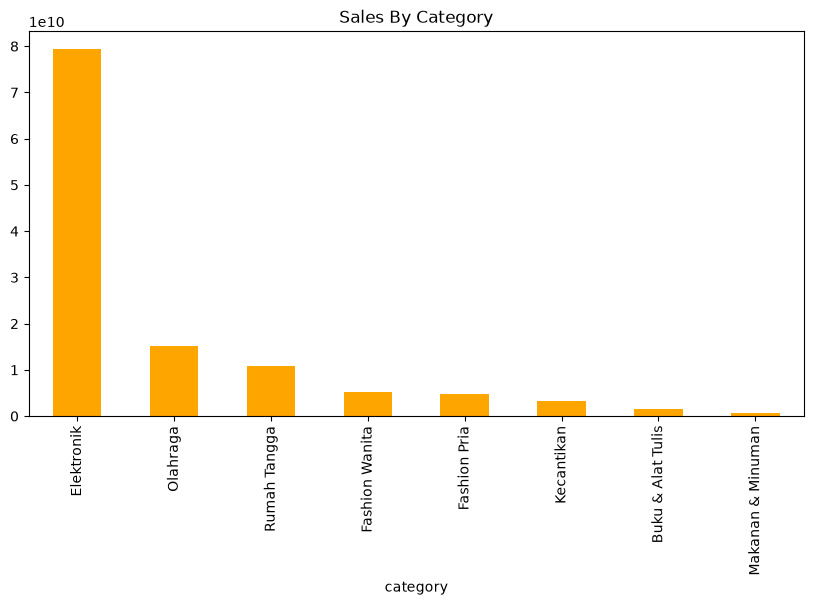

In [118]:
category_sales.plot(
    kind='bar',
    figsize=(10, 5),
    color='orange'
)

plt.title("Sales By Category")
plt.show()

In [122]:
category_quantity = df.groupby("category")['quantity'].sum().sort_values(ascending=False)
category_quantity

category
Fashion Wanita       12596
Fashion Pria         12453
Elektronik           12415
Rumah Tangga         10993
Buku & Alat Tulis    10953
Olahraga             10930
Kecantikan           10714
Makanan & Minuman    10667
Name: quantity, dtype: int64

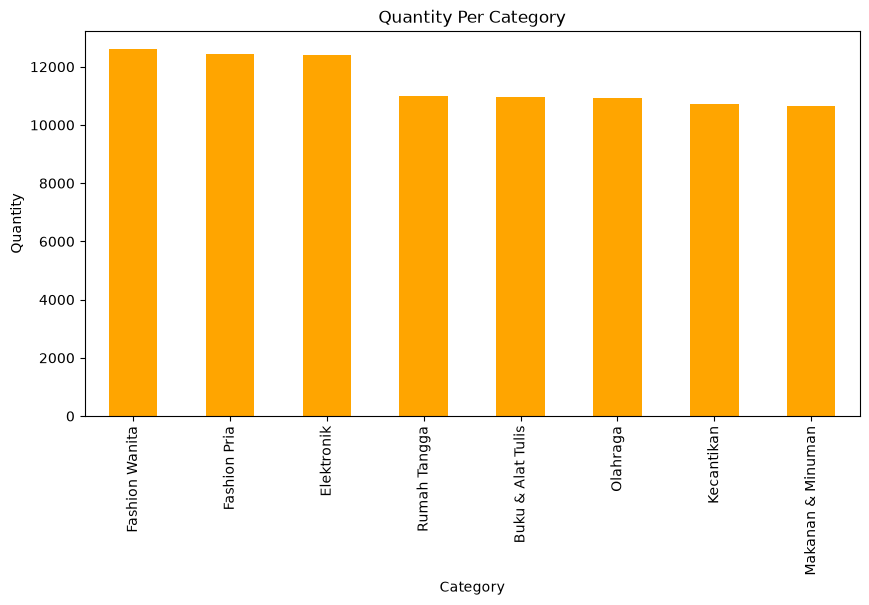

In [125]:
category_quantity.plot(
    kind='bar',
    figsize=(10, 5),
    color='orange'
)
plt.xlabel("Category")
plt.ylabel("Quantity")
plt.title("Quantity Per Category")
plt.show()

In [126]:
category_unit_price = df.groupby("category")["unit_price"].mean().sort_values(ascending=False)
category_unit_price

category
Elektronik           7.050642e+06
Olahraga             1.521135e+06
Rumah Tangga         1.065604e+06
Fashion Wanita       4.519768e+05
Fashion Pria         4.100814e+05
Kecantikan           3.361518e+05
Buku & Alat Tulis    1.482898e+05
Makanan & Minuman    7.201349e+04
Name: unit_price, dtype: float64

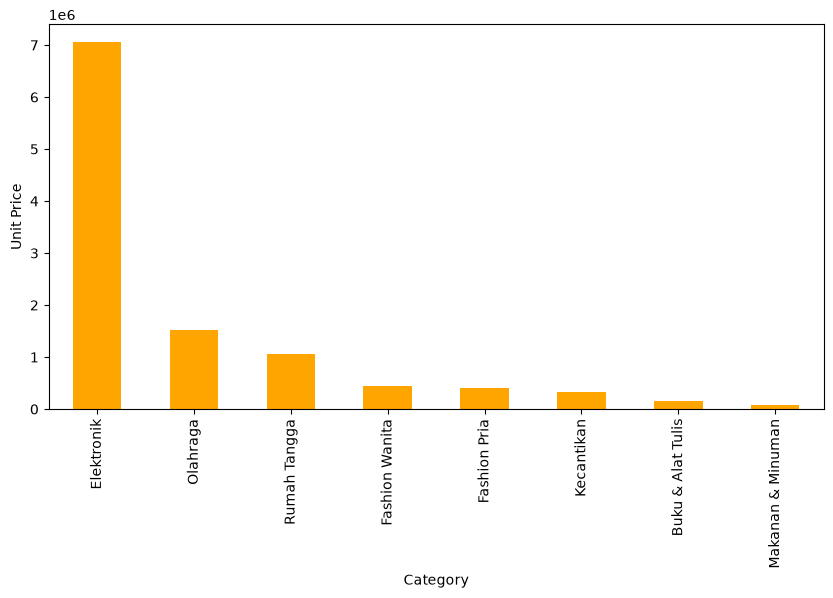

In [129]:
category_unit_price.plot(
    kind='bar',
    figsize=(10, 5),
    color='orange'
)

plt.xlabel("Category")
plt.ylabel("Unit Price")
plt.show()

In [131]:
avg_total_amount = df.groupby("category")["total_amount"].mean().sort_values(ascending=False)
avg_total_amount

category
Elektronik           1.169365e+07
Olahraga             2.538649e+06
Rumah Tangga         1.781264e+06
Fashion Wanita       7.511899e+05
Fashion Pria         6.926432e+05
Kecantikan           5.597165e+05
Buku & Alat Tulis    2.552032e+05
Makanan & Minuman    1.185349e+05
Name: total_amount, dtype: float64

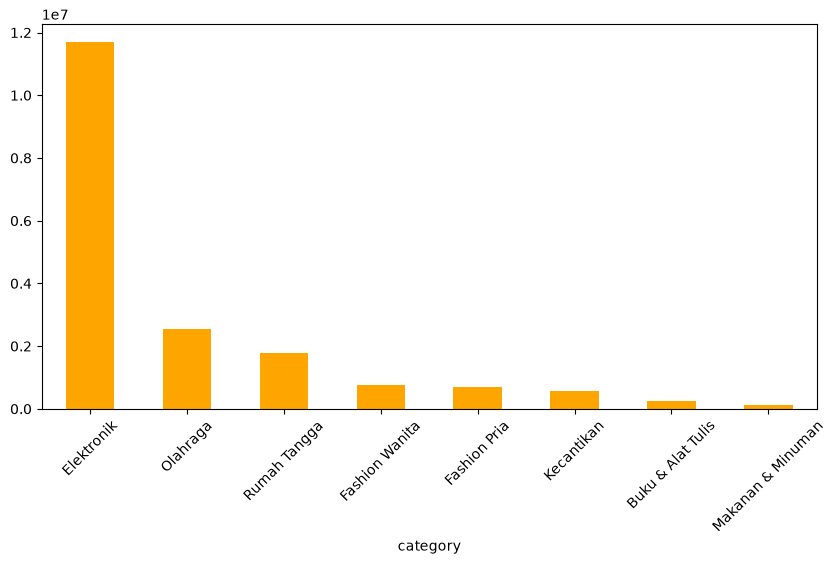

In [143]:
avg_total_amount.plot(
    kind='bar',
    figsize=(10, 5),
    color='orange'
)
plt.xticks(rotation=45)
plt.show()

In [134]:
payment_sales = (
    df.groupby("payment_method")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

payment_sales

payment_method
E-Wallet         38585001800
Transfer Bank    36128642000
COD              18152006300
Kartu Kredit     16320788300
QRIS             11296945800
Name: total_amount, dtype: int64

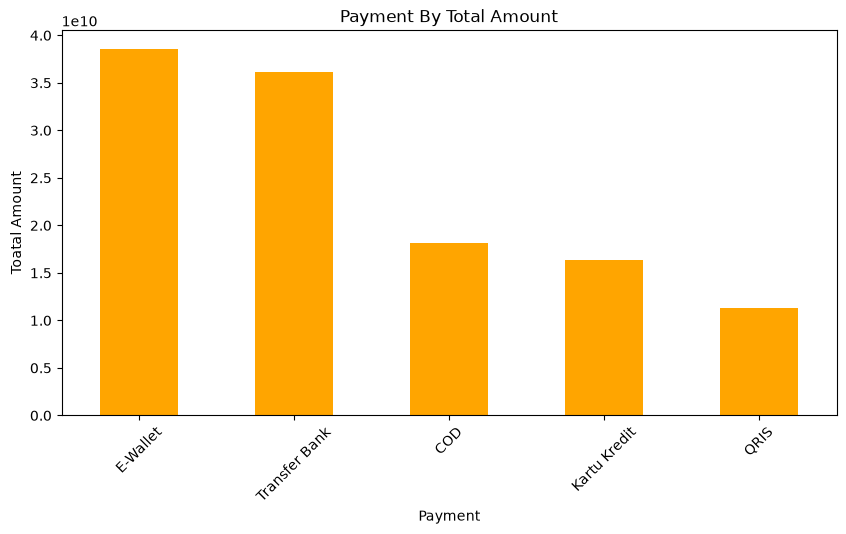

In [142]:
payment_sales.plot(
    kind='bar',
    figsize=(10, 5),
    color='orange'

)

plt.xlabel("Payment")
plt.ylabel("Toatal Amount")
plt.title("Payment By Total Amount")
plt.xticks(rotation=45)
plt.show()

In [138]:
payment_quantity = df.groupby("payment_method")["quantity"].sum().sort_values(ascending=False)
payment_quantity

payment_method
E-Wallet         29233
Transfer Bank    27326
COD              13981
Kartu Kredit     12229
QRIS              8952
Name: quantity, dtype: int64

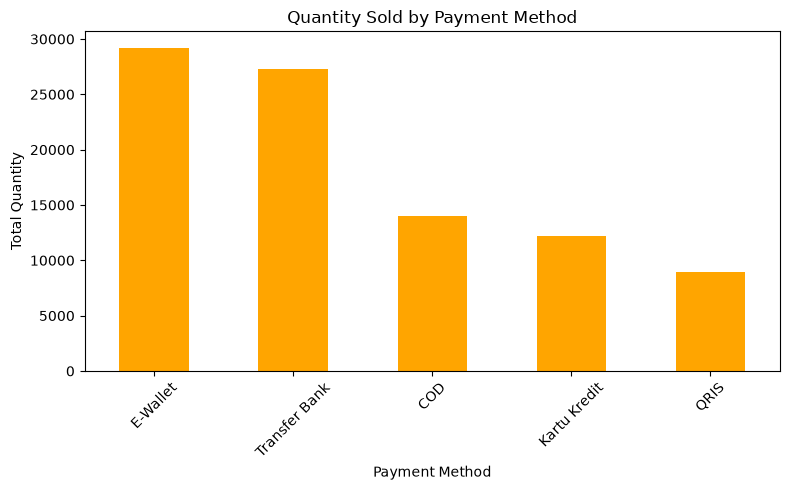

In [141]:
payment_quantity.plot(
    kind="bar",
    figsize=(8, 5),
    color='orange'
)

plt.xlabel("Payment Method")
plt.ylabel("Total Quantity")
plt.title("Quantity Sold by Payment Method")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [145]:
gender_sales = df.groupby("customer_gender")["total_amount"].sum().sort_values(ascending=False)
gender_sales

customer_gender
Perempuan    60567929000
Laki-laki    59915455200
Name: total_amount, dtype: int64

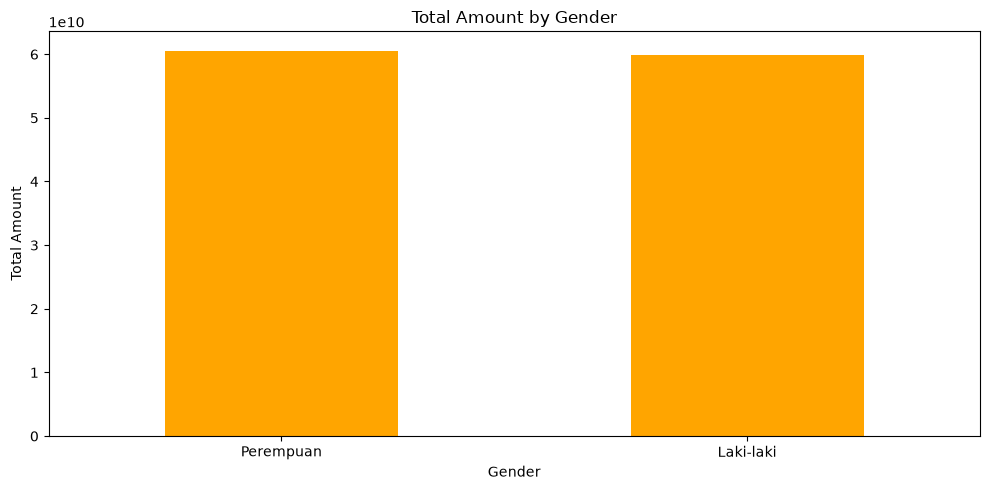

In [146]:
gender_sales.plot(
    kind='bar',
    figsize=(10, 5),
    color='orange'
)
plt.xlabel("Gender")
plt.ylabel("Total Amount")
plt.title("Total Amount by Gender")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [147]:
gender_quantity = df.groupby("customer_gender")["quantity"].sum().sort_values(ascending=False)
gender_quantity

customer_gender
Laki-laki    46929
Perempuan    44792
Name: quantity, dtype: int64

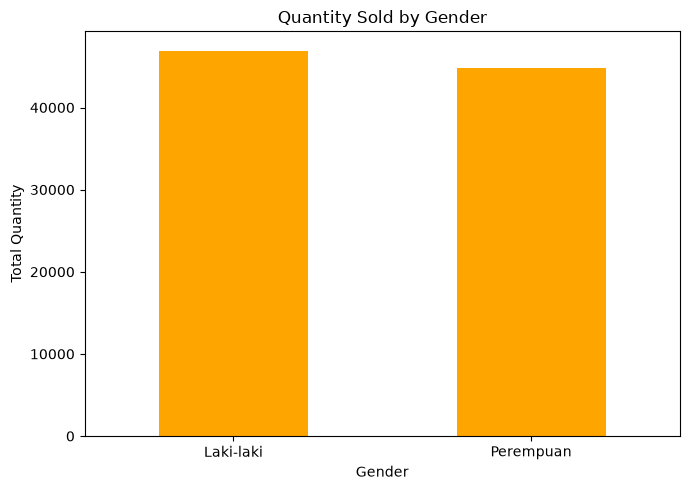

In [150]:
gender_quantity.plot(
    kind="bar",
    figsize=(7, 5),
    color="orange"
)

plt.xlabel("Gender")
plt.ylabel("Total Quantity")
plt.title("Quantity Sold by Gender")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

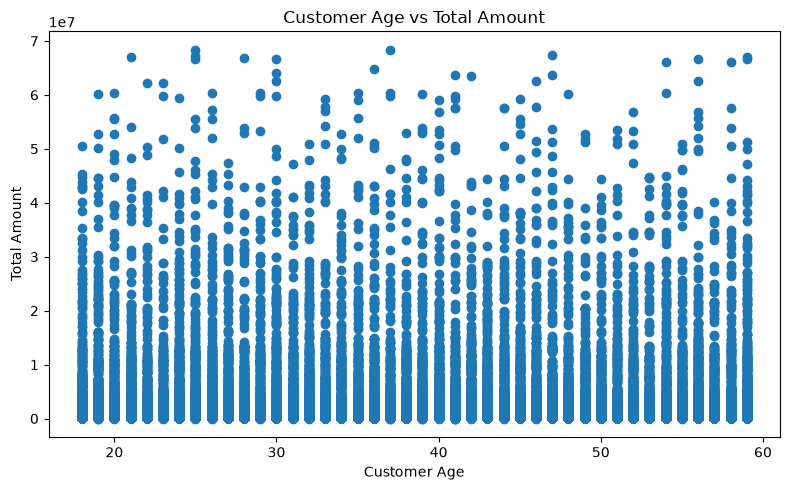

In [151]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["customer_age"],
    df["total_amount"]
)

plt.xlabel("Customer Age")
plt.ylabel("Total Amount")
plt.title("Customer Age vs Total Amount")

plt.tight_layout()
plt.show()

In [152]:
df["customer_age"].corr(df["total_amount"])

np.float64(-0.008088411412892559)

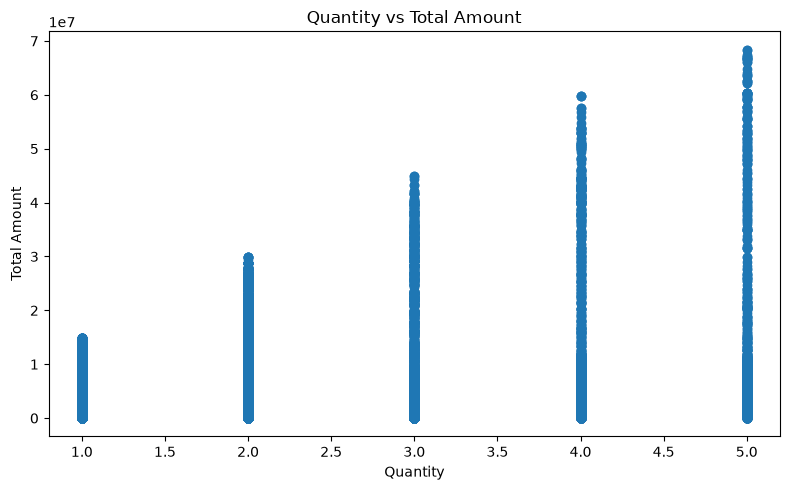

In [153]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["quantity"],
    df["total_amount"]
)

plt.xlabel("Quantity")
plt.ylabel("Total Amount")
plt.title("Quantity vs Total Amount")

plt.tight_layout()
plt.show()

In [154]:
df["quantity"].corr(df["total_amount"])

np.float64(0.2592225806702939)

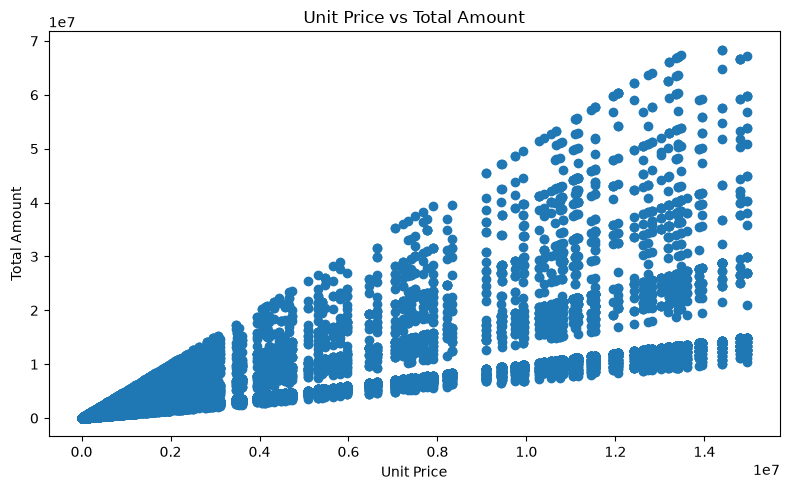

In [155]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["unit_price"],
    df["total_amount"]
)

plt.xlabel("Unit Price")
plt.ylabel("Total Amount")
plt.title("Unit Price vs Total Amount")

plt.tight_layout()
plt.show()

In [156]:
df["unit_price"].corr(df["total_amount"])

np.float64(0.8139217491351521)

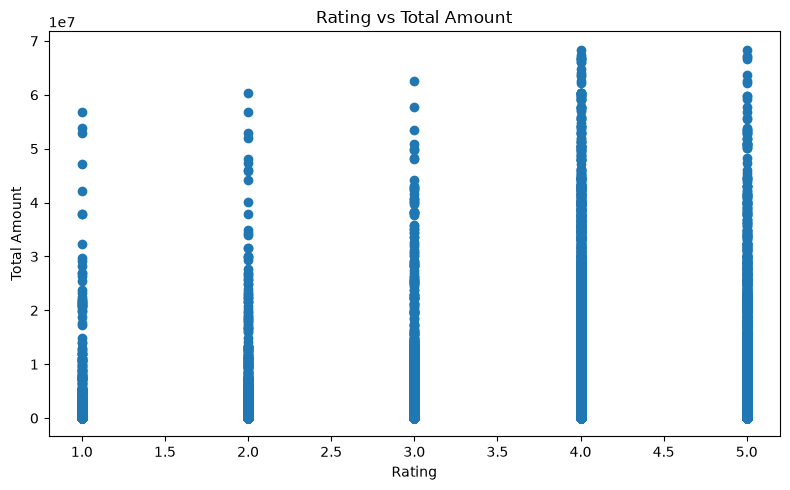

In [157]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["rating"],
    df["total_amount"]
)

plt.xlabel("Rating")
plt.ylabel("Total Amount")
plt.title("Rating vs Total Amount")

plt.tight_layout()
plt.show()

In [158]:
df["rating"].corr(df["total_amount"])

np.float64(-0.0017690468066308513)

In [159]:
gender_category = pd.crosstab(
    df["customer_gender"],
    df["category"]
)

gender_category

category,Buku & Alat Tulis,Elektronik,Fashion Pria,Fashion Wanita,Kecantikan,Makanan & Minuman,Olahraga,Rumah Tangga
customer_gender,,,,,,,,
Laki-laki,3003,3406,3492,3532,3043,3075,2994,3069
Perempuan,2838,3376,3261,3385,2806,2806,2958,2956


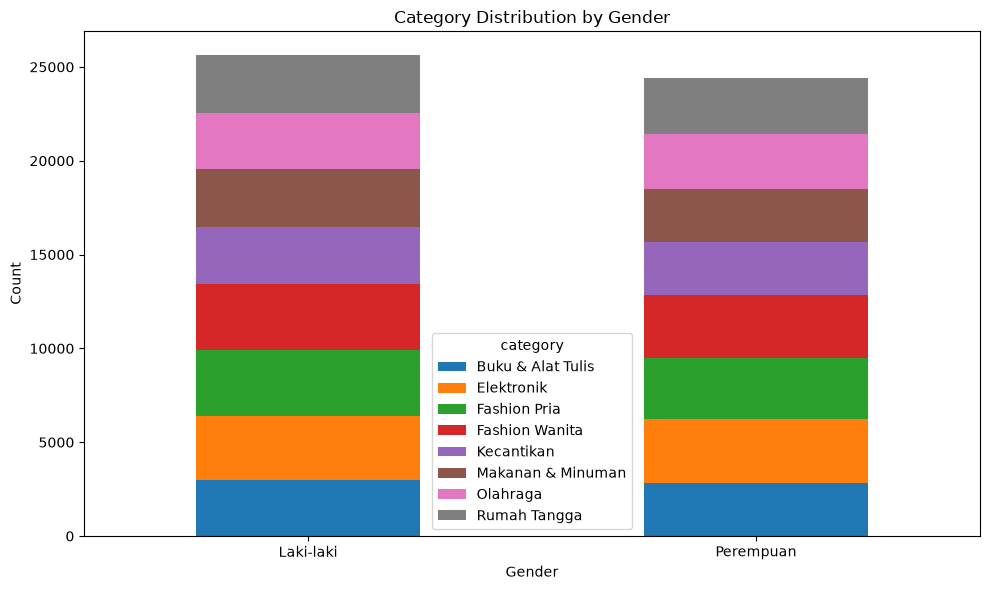

In [160]:
gender_category.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Category Distribution by Gender")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [161]:
gender_category_pct = pd.crosstab(
    df["customer_gender"],
    df["category"],
    normalize="index"
) * 100

gender_category_pct.round(2)


category,Buku & Alat Tulis,Elektronik,Fashion Pria,Fashion Wanita,Kecantikan,Makanan & Minuman,Olahraga,Rumah Tangga
customer_gender,,,,,,,,
Laki-laki,11.72,13.30,13.63,13.79,11.88,12.01,11.69,11.98
Perempuan,11.64,13.84,13.37,13.88,11.51,11.51,12.13,12.12


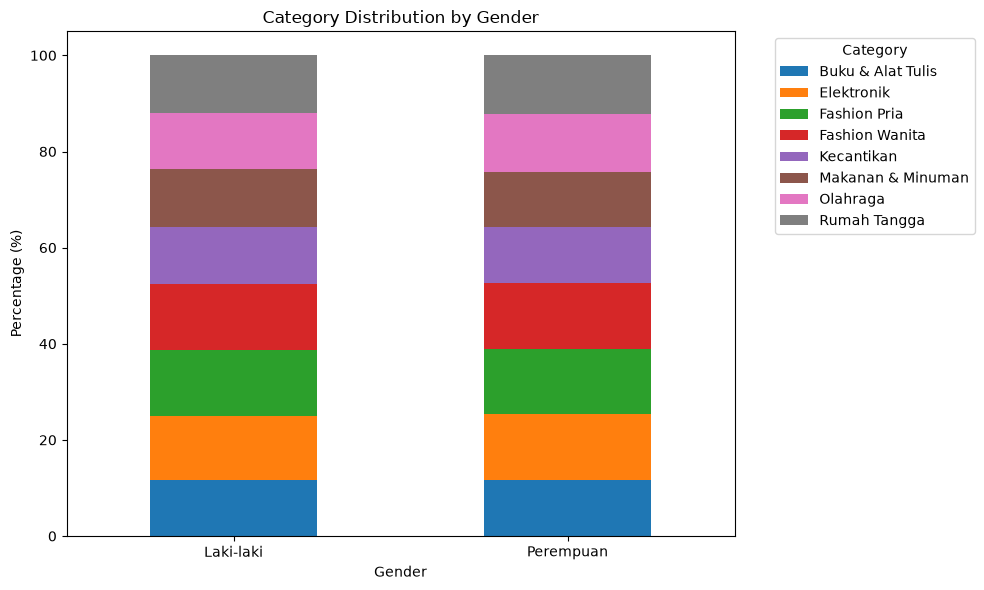

In [162]:
gender_category_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.title("Category Distribution by Gender")
plt.xticks(rotation=0)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [163]:
gender_payment = pd.crosstab(
    df["customer_gender"],
    df["payment_method"]
)

gender_payment

payment_method,COD,E-Wallet,Kartu Kredit,QRIS,Transfer Bank
customer_gender,,,,,
Laki-laki,3863,8121,3407,2518,7705
Perempuan,3665,7844,3233,2388,7256


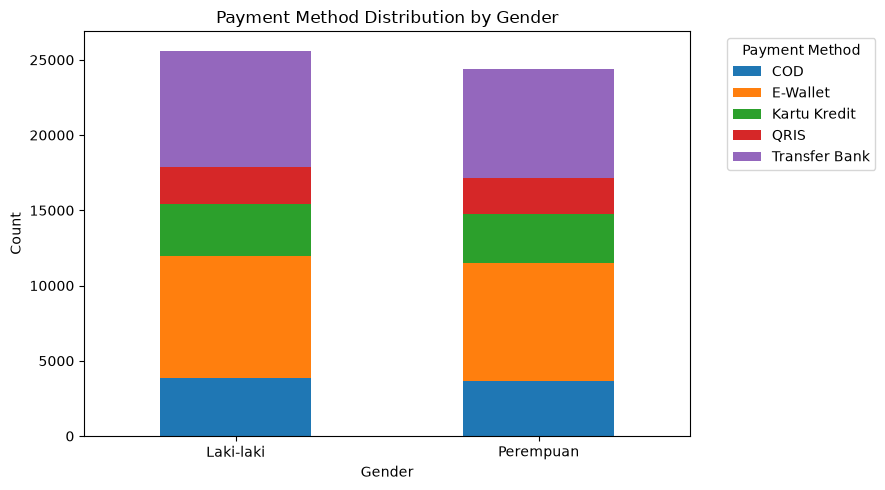

In [164]:
gender_payment.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Payment Method Distribution by Gender")
plt.xticks(rotation=0)
plt.legend(title="Payment Method", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [165]:
status_payment = pd.crosstab(
    df["order_status"],
    df["payment_method"]
)

status_payment

payment_method,COD,E-Wallet,Kartu Kredit,QRIS,Transfer Bank
order_status,,,,,
Dibatalkan,601,1322,513,389,1155
Dikembalikan,453,950,412,288,899
Diproses,624,1259,474,403,1220
Selesai,5850,12434,5241,3826,11687


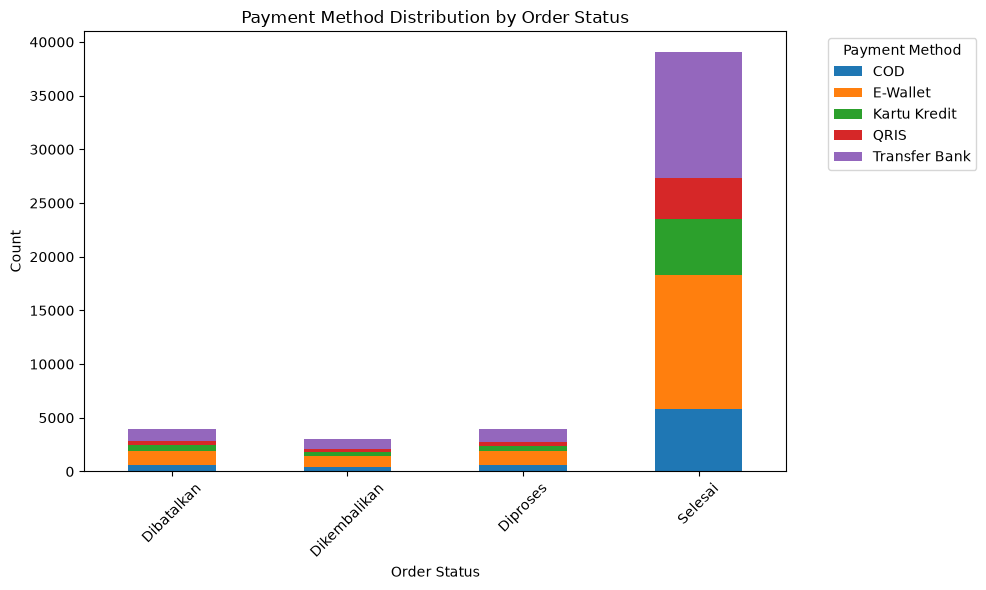

In [166]:
status_payment.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.xlabel("Order Status")
plt.ylabel("Count")
plt.title("Payment Method Distribution by Order Status")
plt.xticks(rotation=45)
plt.legend(
    title="Payment Method",
    bbox_to_anchor=(1.05, 1)
)
plt.tight_layout()
plt.show()

In [167]:
status_sales = (
    df.groupby("order_status")["total_amount"]
      .sum()
      .sort_values(ascending=False)
)

status_sales

order_status
Selesai         93877761900
Diproses        10198101800
Dibatalkan       9320240100
Dikembalikan     7087280400
Name: total_amount, dtype: int64

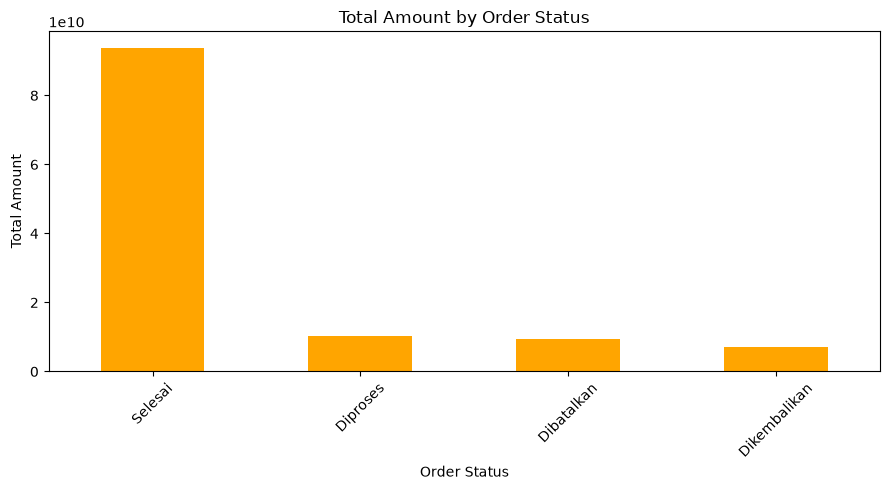

In [169]:
status_sales.plot(
    kind="bar",
    figsize=(9, 5),
    color="orange"
)

plt.xlabel("Order Status")
plt.ylabel("Total Amount")
plt.title("Total Amount by Order Status")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [170]:
status_quantity = (
    df.groupby("order_status")["quantity"]
      .sum()
      .sort_values(ascending=False)
)

status_quantity

order_status
Selesai         71469
Dibatalkan       7424
Diproses         7358
Dikembalikan     5470
Name: quantity, dtype: int64

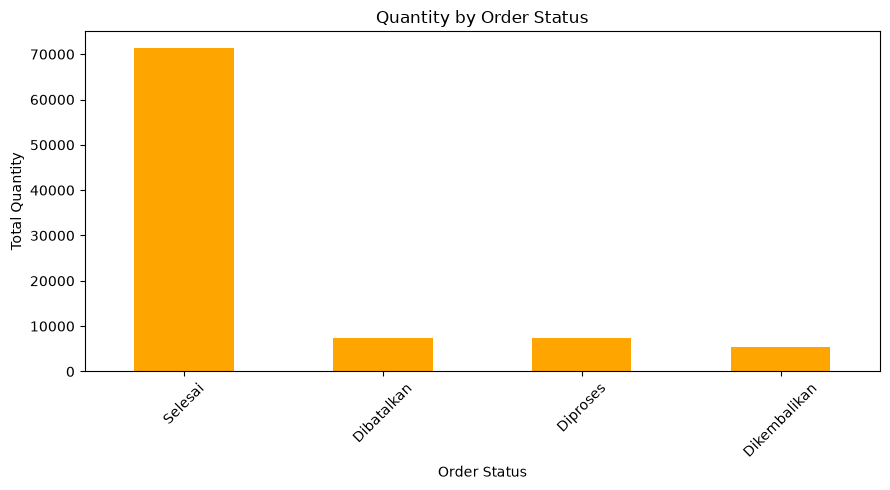

In [172]:
status_quantity.plot(
    kind="bar",
    figsize=(9, 5),
    color="orange"
)

plt.xlabel("Order Status")
plt.ylabel("Total Quantity")
plt.title("Quantity by Order Status")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [173]:
status_price = (
    df.groupby("order_status")["unit_price"]
      .mean()
      .sort_values(ascending=False)
)

status_price

order_status
Diproses        1.500002e+06
Dikembalikan    1.468611e+06
Selesai         1.448442e+06
Dibatalkan      1.386906e+06
Name: unit_price, dtype: float64

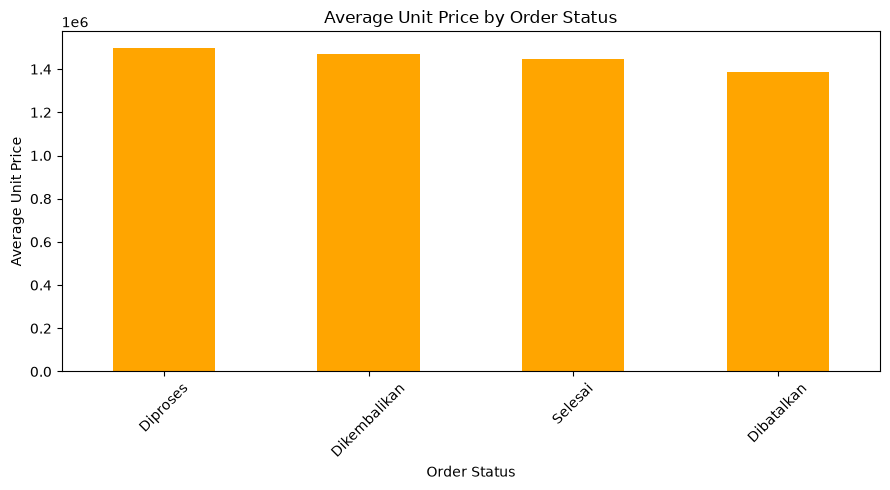

In [175]:
status_price.plot(
    kind="bar",
    figsize=(9, 5),
    color="orange"
)

plt.xlabel("Order Status")
plt.ylabel("Average Unit Price")
plt.title("Average Unit Price by Order Status")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [176]:
category_payment = pd.crosstab(
    df["category"],
    df["payment_method"]
)

category_payment

payment_method,COD,E-Wallet,Kartu Kredit,QRIS,Transfer Bank
category,,,,,
Buku & Alat Tulis,912,1830,747,570,1782
Elektronik,980,2189,930,651,2032
Fashion Pria,1044,2100,911,643,2055
Fashion Wanita,1032,2244,882,681,2078
Kecantikan,913,1872,776,572,1716
Makanan & Minuman,893,1902,822,575,1689
Olahraga,848,1938,781,594,1791
Rumah Tangga,906,1890,791,620,1818


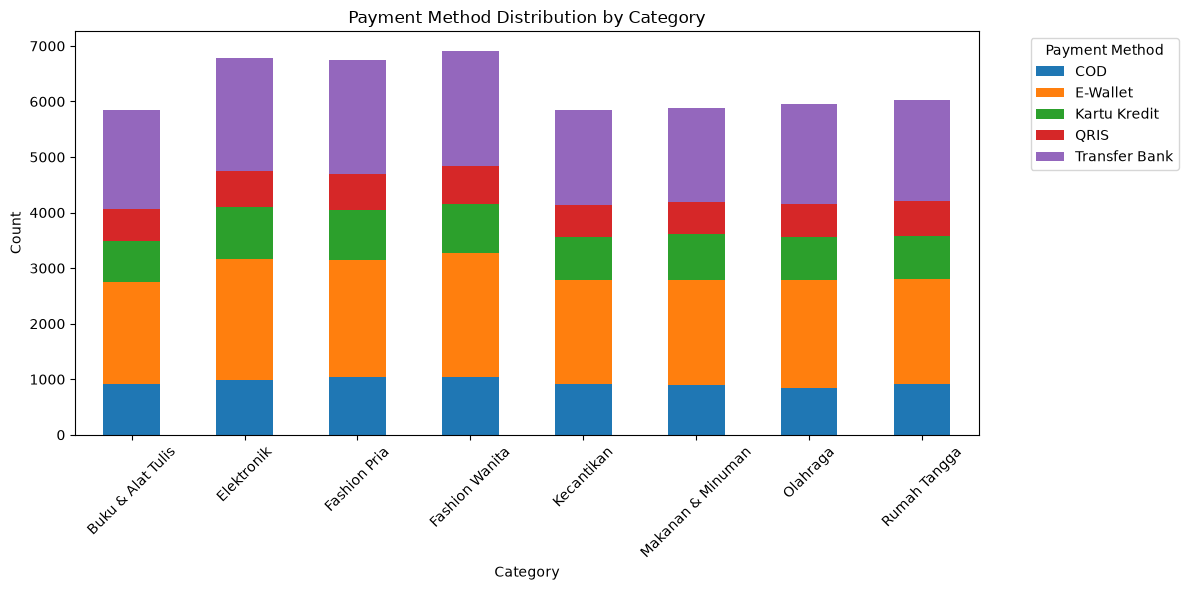

In [177]:
category_payment.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Payment Method Distribution by Category")
plt.xticks(rotation=45)
plt.legend(
    title="Payment Method",
    bbox_to_anchor=(1.05, 1)
)
plt.tight_layout()
plt.show()

In [178]:
category_payment_pct = pd.crosstab(
    df["category"],
    df["payment_method"],
    normalize="index"
) * 100

category_payment_pct.round(2)

payment_method,COD,E-Wallet,Kartu Kredit,QRIS,Transfer Bank
category,,,,,
Buku & Alat Tulis,15.61,31.33,12.79,9.76,30.51
Elektronik,14.45,32.28,13.71,9.60,29.96
Fashion Pria,15.46,31.10,13.49,9.52,30.43
Fashion Wanita,14.92,32.44,12.75,9.85,30.04
Kecantikan,15.61,32.01,13.27,9.78,29.34
Makanan & Minuman,15.18,32.34,13.98,9.78,28.72
Olahraga,14.25,32.56,13.12,9.98,30.09
Rumah Tangga,15.04,31.37,13.13,10.29,30.17


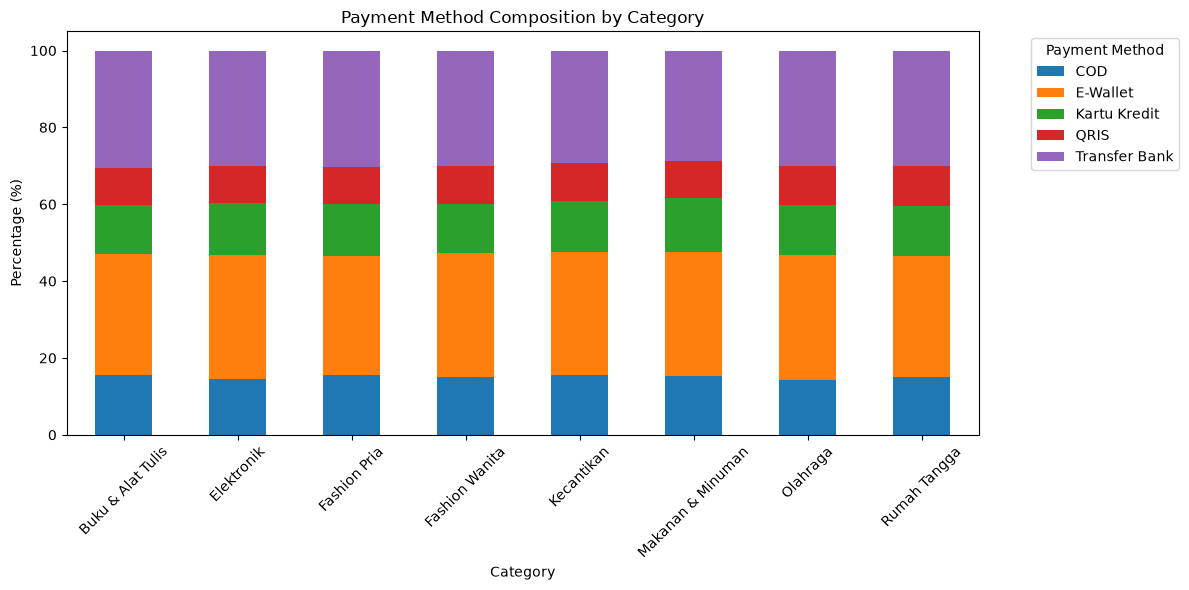

In [179]:
category_payment_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.xlabel("Category")
plt.ylabel("Percentage (%)")
plt.title("Payment Method Composition by Category")
plt.xticks(rotation=45)
plt.legend(
    title="Payment Method",
    bbox_to_anchor=(1.05, 1)
)
plt.tight_layout()
plt.show()

In [180]:
category_status = pd.crosstab(
    df["category"],
    df["order_status"]
)

category_status

order_status,Dibatalkan,Dikembalikan,Diproses,Selesai
category,,,,
Buku & Alat Tulis,489,339,453,4560
Elektronik,513,424,569,5276
Fashion Pria,556,410,545,5242
Fashion Wanita,508,421,534,5454
Kecantikan,455,335,514,4545
Makanan & Minuman,488,367,452,4574
Olahraga,487,346,445,4674
Rumah Tangga,484,360,468,4713


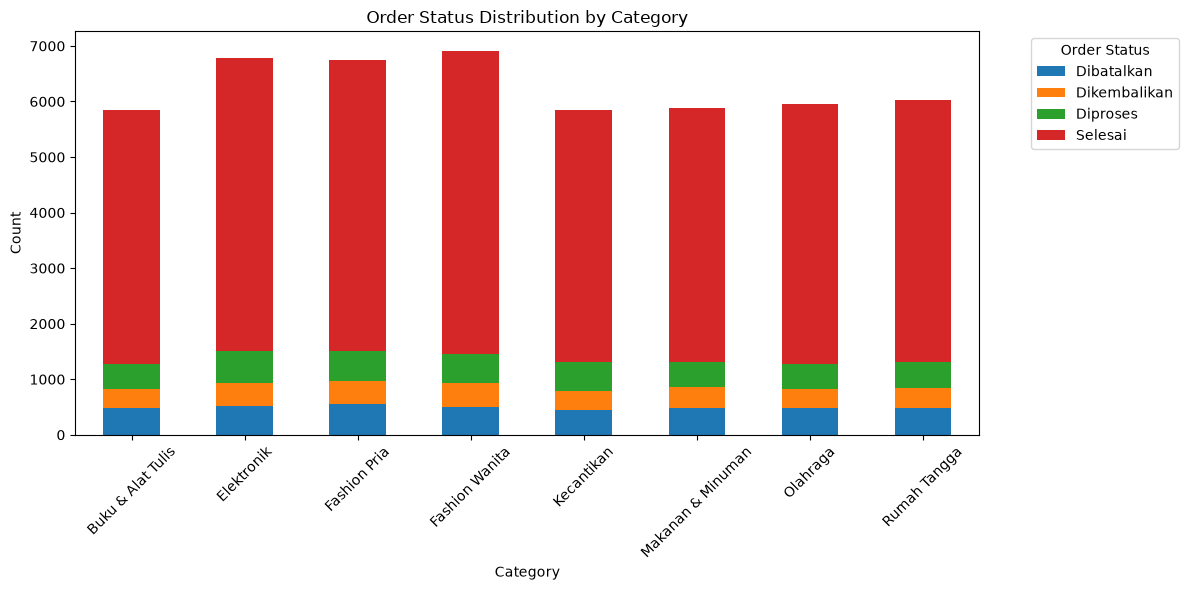

In [181]:
category_status.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Order Status Distribution by Category")
plt.xticks(rotation=45)
plt.legend(
    title="Order Status",
    bbox_to_anchor=(1.05, 1)
)

plt.tight_layout()
plt.show()

In [182]:
payment_status_pct = pd.crosstab(
    df["payment_method"],
    df["order_status"],
    normalize="index"
) * 100

payment_status_pct.round(2)

order_status,Dibatalkan,Dikembalikan,Diproses,Selesai
payment_method,,,,
COD,7.98,6.02,8.29,77.71
E-Wallet,8.28,5.95,7.89,77.88
Kartu Kredit,7.73,6.20,7.14,78.93
QRIS,7.93,5.87,8.21,77.99
Transfer Bank,7.72,6.01,8.15,78.12


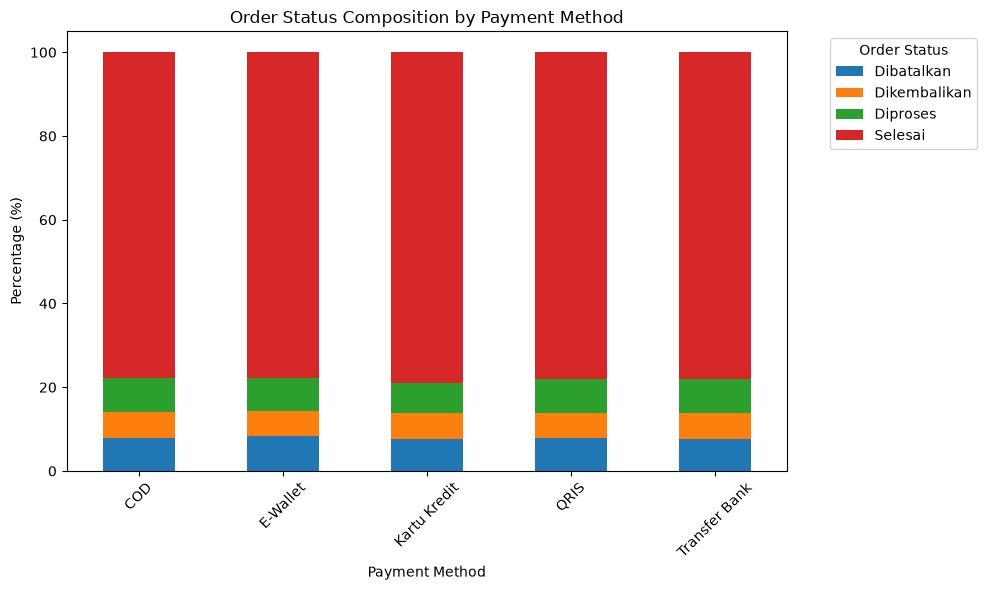

In [183]:
payment_status_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.xlabel("Payment Method")
plt.ylabel("Percentage (%)")
plt.title("Order Status Composition by Payment Method")
plt.xticks(rotation=45)

plt.legend(
    title="Order Status",
    bbox_to_anchor=(1.05, 1)
)

plt.tight_layout()
plt.show()

In [187]:
monthly_sales = (
    df.groupby("order_month")["total_amount"]
      .sum()
      .sort_index()
)

monthly_sales

order_month
1     10081911700
2      8925727000
3      9785910900
4     10796557100
5     10892052800
6     10257658300
7      9798292900
8      9377577600
9     10581867000
10    10006527800
11    10154980200
12     9824320900
Name: total_amount, dtype: int64

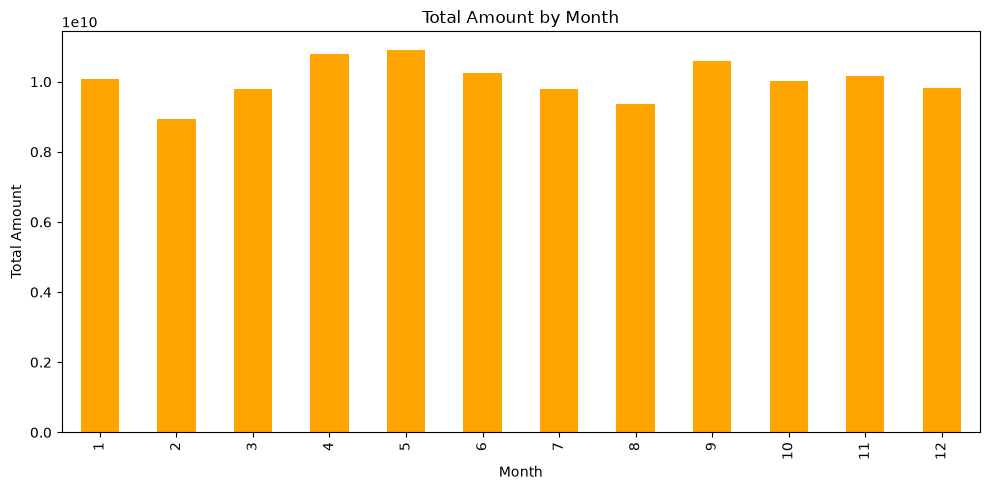

In [189]:
monthly_sales.plot(
    kind="bar",
    figsize=(10, 5),
    color='Orange'
)

plt.xlabel("Month")
plt.ylabel("Total Amount")
plt.title("Total Amount by Month")
plt.tight_layout()
plt.show()

In [190]:
category_analysis = (
    df.groupby("category")
      .agg(
          total_sales=("total_amount", "sum"),
          total_quantity=("quantity", "sum"),
          avg_unit_price=("unit_price", "mean"),
          transaction_count=("order_id", "nunique")
      )
      .sort_values("total_sales", ascending=False)
)

category_analysis

,total_sales,total_quantity,avg_unit_price,transaction_count
category,,,,
Elektronik,79306300700,12415,7.050642e+06,6782
Olahraga,15110041000,10930,1.521135e+06,5952
Rumah Tangga,10732115700,10993,1.065604e+06,6025
Fashion Wanita,5195980500,12596,4.519768e+05,6917
Fashion Pria,4677419300,12453,4.100814e+05,6753
Kecantikan,3273781800,10714,3.361518e+05,5849
Buku & Alat Tulis,1490641700,10953,1.482898e+05,5841
Makanan & Minuman,697103500,10667,7.201349e+04,5881
